In [1]:
# ********** Importación de Bibliotecas ***************
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk import FreqDist, pos_tag, ne_chunk
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# ********** Descargar Recursos Necesarios de NLTK ***************
nltk.download('punkt')
nltk.download('stopwords')  # Palabras vacías
nltk.download('wordnet')  # Lematización
nltk.download('averaged_perceptron_tagger')  # Etiquetado de palabras
nltk.download('vader_lexicon')  # Para análisis de sentimientos
nltk.download('maxent_ne_chunker_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')
nltk.download('words')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cutza\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cutza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\cutza\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\cutza\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\cutza\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\cutza\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_ch

True

In [2]:
# ********** Cargar Datos ***************
try:
    df = pd.read_csv('data/Datos.csv')
    print("Datos cargados correctamente.")
except FileNotFoundError:
    print("El archivo de datos no fue encontrado.")
    exit()
print(df.head())

Datos cargados correctamente.
                                        Course Title  Rating           Level  \
0                                  Fashion as Design     4.8  Beginner level   
1                             Modern American Poetry     4.4  Beginner level   
2                          Pixel Art for Video Games     4.5  Beginner level   
3    Distribución digital de la música independiente     NaN  Beginner level   
4  The Blues: Understanding and Performing an Ame...     4.8  Beginner level   

                       Duration           Schedule         Review  \
0      20 hours (approximately)  Flexible schedule  2,813 reviews   
1  Approx. 34 hours to complete  Flexible schedule    100 reviews   
2       9 hours (approximately)  Flexible schedule    227 reviews   
3   Approx. 8 hours to complete  Flexible schedule            NaN   
4  Approx. 11 hours to complete  Flexible schedule    582 reviews   

                                 What you will learn  \
0                 

In [3]:
# Procesar la columna 'Duration' para extraer solo el número
def convertir_duracion(duracion):
    try:
        return float(duracion.split()[0])
    except:
        return None

# Aplicar la función a la columna Duration
df['Duration'] = df['Duration'].apply(convertir_duracion)

# Procesar la columna 'Review' para extraer solo el número
def convertir_revisiones(revision):
    try:
        return int(revision.split()[0].replace(',', ''))
    except:
        return None

# Aplicar la función a la columna Review
df['Review'] = df['Review'].apply(convertir_revisiones)

df = df[(df['Duration'].notnull()) & (df['Review'].notnull())]

print(df.isnull().sum())
df.dropna(inplace=True)

Course Title              0
Rating                    0
Level                   408
Duration                  0
Schedule                254
Review                    0
What you will learn    1835
Skill gain                0
Modules                   0
Instructor                0
Offered By                0
Keyword                   0
Course Url                0
dtype: int64


In [4]:
def cambiar_tipos_de_datos(df):
    if 'Duration' in df.columns:
        df['Duration'] = df['Duration'].astype(str)
        df['Duration'] = df['Duration'].str.extract(r'(\d+)').astype(float)  # Cambiar a float
    else:
        print("La columna 'Duration' no existe en los datos.")

    if 'Rating' in df.columns:
        df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
    else:
        print("La columna 'Rating' no existe en los datos.")

    if 'Review' in df.columns:
        df['Review'] = df['Review'].astype(str)
        df['Review'] = df['Review'].str.replace(' reviews', '', regex=False)  # Eliminar 'reviews'
        df['Review'] = pd.to_numeric(df['Review'].str.replace(',', ''), errors='coerce')  # Convertir a numérico
    else:
        print("La columna 'Review' no existe en los datos.")

    return df

df = cambiar_tipos_de_datos(df)

In [5]:
# ********** Análisis de Datos ***************
# Cálculo del Promedio de Calificaciones por Curso
if 'Course Title' in df.columns and 'Rating' in df.columns:
    promedio_calificaciones = df.groupby('Course Title')['Rating'].mean()
    print(promedio_calificaciones)
else:
    print("Las columnas 'Course Title' o 'Rating' no están disponibles para calcular el promedio.")

# Cursos con Mayor y Menor Rating
if 'Rating' in df.columns:
    curso_mayor_rating = df.loc[df['Rating'].idxmax()]
    curso_menor_rating = df.loc[df['Rating'].idxmin()]
    print(f"Curso con mayor rating: {curso_mayor_rating['Course Title']} con un rating de {curso_mayor_rating['Rating']}")
    print(f"Curso con menor rating: {curso_menor_rating['Course Title']} con un rating de {curso_menor_rating['Rating']}")
else:
    print("No se puede calcular el curso con mayor o menor rating porque falta la columna 'Rating'.")

# Porcentaje de Cursos con Horario Flexible
if 'Schedule' in df.columns:
    cursos_flexibles = df[df['Schedule'] == 'Flexible schedule']
    porcentaje_flexibles = (len(cursos_flexibles) / len(df)) * 100
    print(f"Porcentaje de cursos con horario flexible: {porcentaje_flexibles:.2f}%")
else:
    print("La columna 'Schedule' no está disponible.")

Course Title
 Assisting Public Sector Decision Makers With Policy Analysis                   4.8
 Comercio, Inmigración y Tipos de Cambio en un Mundo Globalizado                4.9
 Future Healthcare Payment Models                                               4.5
 IBM and ISC2 Cybersecurity Specialist Professional Certificate                 4.8
 Natural Language Processing and Capstone Assignment                            4.7
                                                                               ... 
Цифровий маркетинг і електронна комерція від Google Professional Certificate    4.9
إدارة المشروعات من Google Professional Certificate                              4.7
الإعلان من خلال فيسبوك                                                          4.7
الطاقة المتجددة Specialization                                                  4.8
تحليلات البيانات من Google Professional Certificate                             4.8
Name: Rating, Length: 1606, dtype: float64
Curso con mayor rati

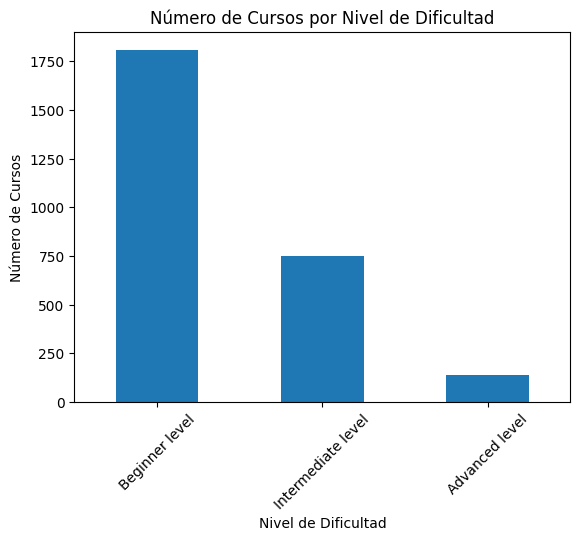

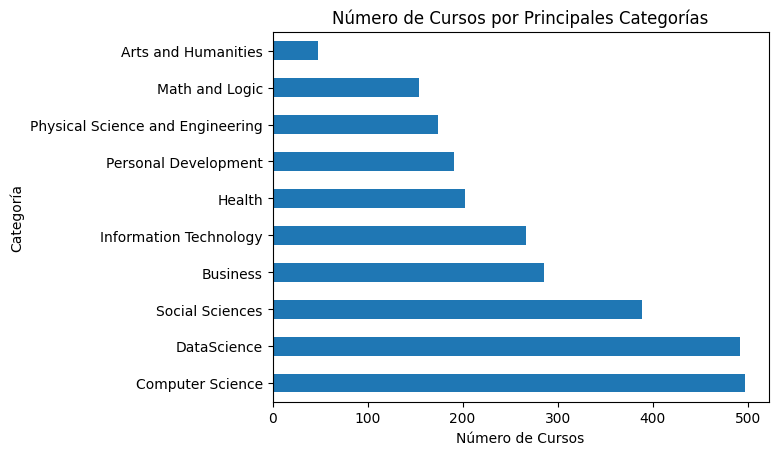

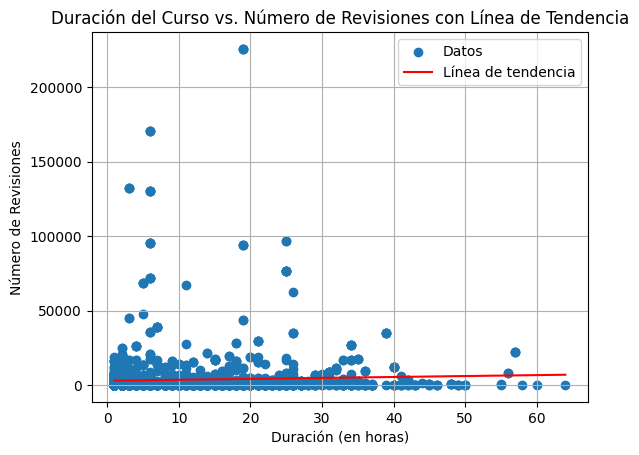

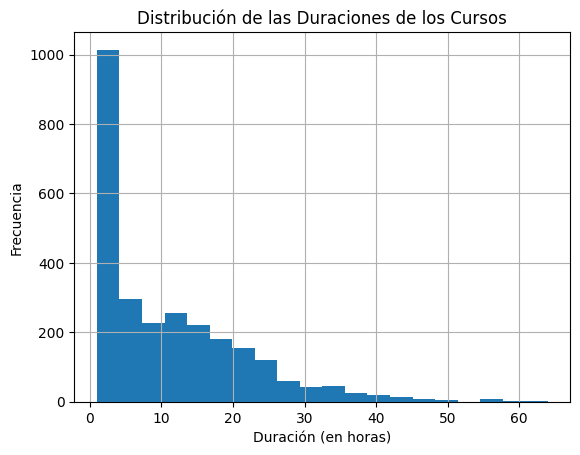

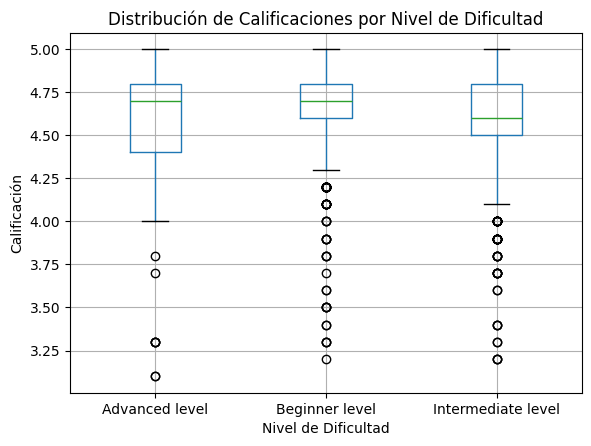

In [6]:
# ********** Visualización de Datos *************** 

# Gráfica de barras (Número de Cursos por Nivel de Dificultad)
if 'Level' in df.columns:
    df['Level'].value_counts().plot(kind='bar')
    plt.title('Número de Cursos por Nivel de Dificultad')
    plt.xlabel('Nivel de Dificultad')
    plt.ylabel('Número de Cursos')
    plt.xticks(rotation=45)
    plt.show()

# Gráfica horizontal (Número de Cursos por Categoría)
if 'Keyword' in df.columns:
    df['Keyword'].value_counts().head(10).plot(kind='barh')
    plt.title('Número de Cursos por Principales Categorías')
    plt.xlabel('Número de Cursos')
    plt.ylabel('Categoría')
    plt.show()

# Gráfica de dispersión (Duración del Curso vs. Número de Revisiones) con línea de tendencia
if 'Duration' in df.columns and 'Review' in df.columns:
    plt.scatter(df['Duration'], df['Review'], label='Datos')
    
    # Calcular la línea de tendencia
    coef = np.polyfit(df['Duration'], df['Review'], 1)  # Ajuste de recta (grado 1)
    polinomio = np.poly1d(coef)
    
    # Generar valores para la línea de tendencia
    x_line = np.linspace(df['Duration'].min(), df['Duration'].max(), 100)
    y_line = polinomio(x_line)
    
    # Graficar la línea de tendencia
    plt.plot(x_line, y_line, color='red', label='Línea de tendencia')
    
    plt.title('Duración del Curso vs. Número de Revisiones con Línea de Tendencia')
    plt.xlabel('Duración (en horas)')
    plt.ylabel('Número de Revisiones')
    plt.grid(True)
    plt.legend()
    plt.show()
    
# Histograma de Duraciones de los Cursos
if 'Duration' in df.columns:
    df['Duration'].hist(bins=20)
    plt.title('Distribución de las Duraciones de los Cursos')
    plt.xlabel('Duración (en horas)')
    plt.ylabel('Frecuencia')
    plt.show()

# Gráfico de cajas (Distribución de Calificaciones por Nivel de Dificultad)
if 'Rating' in df.columns and 'Level' in df.columns:
    df.boxplot(column='Rating', by='Level')
    plt.title('Distribución de Calificaciones por Nivel de Dificultad')
    plt.suptitle('')
    plt.xlabel('Nivel de Dificultad')
    plt.ylabel('Calificación')
    plt.show()

In [7]:
# ********** Análisis de Texto ***************
def analisis_texto():
    try:
        with open('data/Coursera_Comments.txt', 'r', encoding='utf-8') as file:
            texto = file.read()

        # Tokenización
        tokens = word_tokenize(texto)
        print("Primeros 10 tokens:", tokens[:10])

        # Lematización y Stemming
        stemmer = PorterStemmer()
        lemmatizer = WordNetLemmatizer()

        tokens_stemmed = [stemmer.stem(token) for token in tokens]
        tokens_lemmatized = [lemmatizer.lemmatize(token) for token in tokens]
        print("Primeros 10 tokens lematizados:", tokens_lemmatized[:10])

        # Eliminación de Palabras Vacías
        stop_words = set(stopwords.words('spanish'))
        tokens_sin_vacios = [token for token in tokens if token.lower() not in stop_words]
        print("Primeros 10 tokens sin palabras vacías:", tokens_sin_vacios[:10])

        # Frecuencia de Palabras
        frecuencia = FreqDist(tokens_sin_vacios)
        print("Las 10 palabras más comunes:", frecuencia.most_common(10))

        # Frecuencia de Palabras usando tokens_stemmed
        frecuencia_stemmed = FreqDist(tokens_stemmed)
        print("Las 10 palabras más comunes después del stemming:", frecuencia_stemmed.most_common(10))

        # Análisis de Sentimientos
        sia = SentimentIntensityAnalyzer()
        puntaje_sentimiento = sia.polarity_scores(texto)
        print("Puntuación de Sentimiento:", puntaje_sentimiento)

        # Etiquetado de Partes de la Oración
        etiquetas = pos_tag(tokens)
        print("Primeras 10 etiquetas:", etiquetas[:10])

        # Reconocimiento de Entidades Nombradas
        entidades = ne_chunk(etiquetas)
        print("Reconocimiento de Entidades Nombradas:", entidades)

    except Exception as e:
        print("Ocurrió un error durante el análisis de texto:", str(e))

analisis_texto()


Primeros 10 tokens: ['Abril', 'Vargas', 'Pérez', '3', 'opiniones', 'PT', 'Valorada', 'con', '5', 'estrellas']
Primeros 10 tokens lematizados: ['Abril', 'Vargas', 'Pérez', '3', 'opiniones', 'PT', 'Valorada', 'con', '5', 'estrellas']
Primeros 10 tokens sin palabras vacías: ['Abril', 'Vargas', 'Pérez', '3', 'opiniones', 'PT', 'Valorada', '5', 'estrellas', '5']
Las 10 palabras más comunes: [(',', 6799), ('.', 6702), ('curso', 1297), (':', 887), ('“', 869), ('”', 869), ('Semana', 843), ('-', 839), ('TA', 835), ('participantes', 822)]
Las 10 palabras más comunes después del stemming: [('de', 9896), ('la', 7886), (',', 6799), ('.', 6702), ('que', 6571), ('lo', 5610), ('y', 4696), ('en', 4669), ('el', 3980), ('a', 3502)]
Puntuación de Sentimiento: {'neg': 0.035, 'neu': 0.954, 'pos': 0.011, 'compound': -1.0}
Primeras 10 etiquetas: [('Abril', 'NNP'), ('Vargas', 'NNP'), ('Pérez', 'NNP'), ('3', 'CD'), ('opiniones', 'NNS'), ('PT', 'NNP'), ('Valorada', 'NNP'), ('con', 'VBD'), ('5', 'CD'), ('estrella